### Importing Datasets

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

### Importing Dataset

In [2]:
df = pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Analysis

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.shape

(7043, 21)

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: >

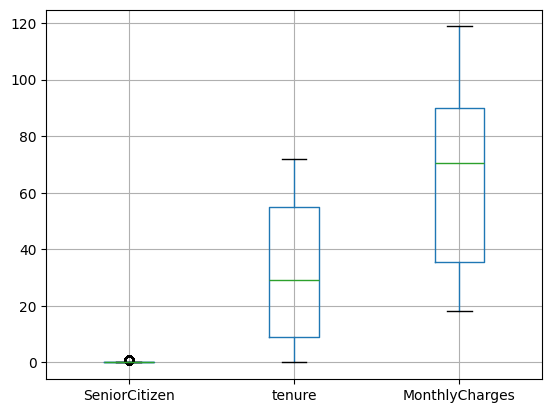

In [7]:
df.boxplot()

In [8]:
import pandas as pd
import numpy as np

# Example: Detect outliers using IQR for all numeric columns
def detect_outliers_iqr(df):
    outliers = {}
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    return outliers

# Usage
outliers_dict = detect_outliers_iqr(df)
print(outliers_dict)

{'SeniorCitizen': 20      1
30      1
31      1
34      1
50      1
       ..
7023    1
7029    1
7031    1
7032    1
7041    1
Name: SeniorCitizen, Length: 1142, dtype: int64, 'tenure': Series([], Name: tenure, dtype: int64), 'MonthlyCharges': Series([], Name: MonthlyCharges, dtype: float64)}


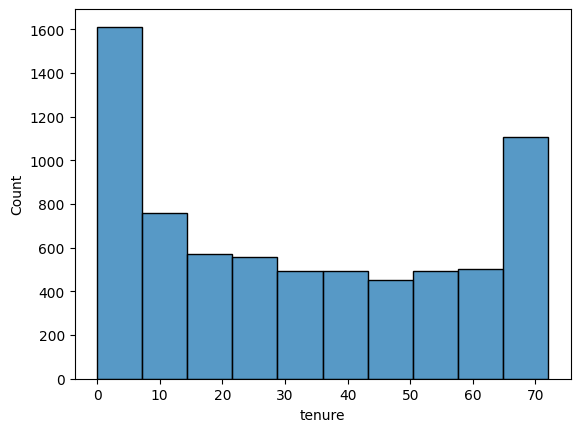

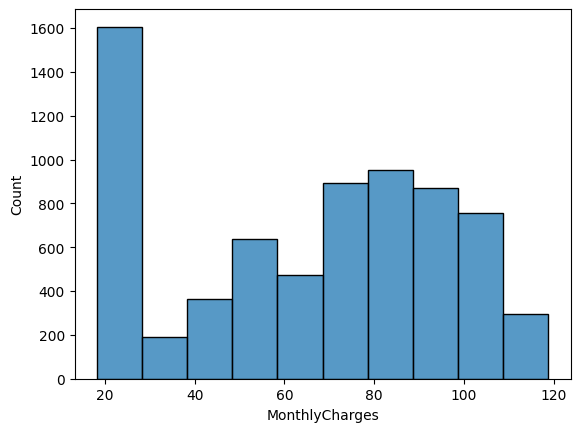

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.histplot(df["tenure"],bins = 10)
plt.show()

sns.histplot(df["MonthlyCharges"],bins = 10)
plt.show()

In [10]:
for i in df.columns:
    print(f"{i}: {df[i].unique()}")

customerID: <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen: [0 1]
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dty

In [11]:
df["Churn"] = df["Churn"].astype(str)
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

df["customerID"] = pd.to_numeric(df["customerID"], errors = "coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors = "coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

high_card_cols = ['customerID','tenure','MonthlyCharges',"TotalCharges"]

# Apply target encoding to each column
for col in high_card_cols:
    df[col + '_target_enc'] = df.groupby(col)['Churn'].transform('mean')

# Drop original high-cardinality columns if you don’t want them
df = df.drop(columns=high_card_cols)

df = pd.get_dummies(df, columns= df.columns.difference(["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]), drop_first=True)

In [12]:
df.head()

,Churn,Contract_One year,Contract_Two year,Dependents_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,InternetService_Fiber optic,InternetService_No,MonthlyCharges_target_enc_0.03571428571428571,MonthlyCharges_target_enc_0.043478260869565216,...,tenure_target_enc_0.36363636363636365,tenure_target_enc_0.37373737373737376,tenure_target_enc_0.3865546218487395,tenure_target_enc_0.3879310344827586,tenure_target_enc_0.3893129770992366,tenure_target_enc_0.47,tenure_target_enc_0.4715909090909091,tenure_target_enc_0.48120300751879697,tenure_target_enc_0.5168067226890757,tenure_target_enc_0.6199021207177814
0,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0,True,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,0,True,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [13]:
df.shape

(7043, 173)

In [14]:
df.dtypes

Churn                                    int64
Contract_One year                         bool
Contract_Two year                         bool
Dependents_Yes                            bool
DeviceProtection_No internet service      bool
                                         ...  
tenure_target_enc_0.47                    bool
tenure_target_enc_0.4715909090909091      bool
tenure_target_enc_0.48120300751879697     bool
tenure_target_enc_0.5168067226890757      bool
tenure_target_enc_0.6199021207177814      bool
Length: 173, dtype: object

In [15]:
df = df.astype({col: "int" for col in df.select_dtypes(include="bool").columns})

In [16]:
min_vals = df.min()
max_vals = df.max()
ranges_df = pd.DataFrame({'min': min_vals, 'max': max_vals, 'range': max_vals - min_vals})
print(ranges_df)

                                       min  max  range
Churn                                    0    1      1
Contract_One year                        0    1      1
Contract_Two year                        0    1      1
Dependents_Yes                           0    1      1
DeviceProtection_No internet service     0    1      1
...                                    ...  ...    ...
tenure_target_enc_0.47                   0    1      1
tenure_target_enc_0.4715909090909091     0    1      1
tenure_target_enc_0.48120300751879697    0    1      1
tenure_target_enc_0.5168067226890757     0    1      1
tenure_target_enc_0.6199021207177814     0    1      1

[173 rows x 3 columns]


In [17]:
df.head()

,Churn,Contract_One year,Contract_Two year,Dependents_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,InternetService_Fiber optic,InternetService_No,MonthlyCharges_target_enc_0.03571428571428571,MonthlyCharges_target_enc_0.043478260869565216,...,tenure_target_enc_0.36363636363636365,tenure_target_enc_0.37373737373737376,tenure_target_enc_0.3865546218487395,tenure_target_enc_0.3879310344827586,tenure_target_enc_0.3893129770992366,tenure_target_enc_0.47,tenure_target_enc_0.4715909090909091,tenure_target_enc_0.48120300751879697,tenure_target_enc_0.5168067226890757,tenure_target_enc_0.6199021207177814
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


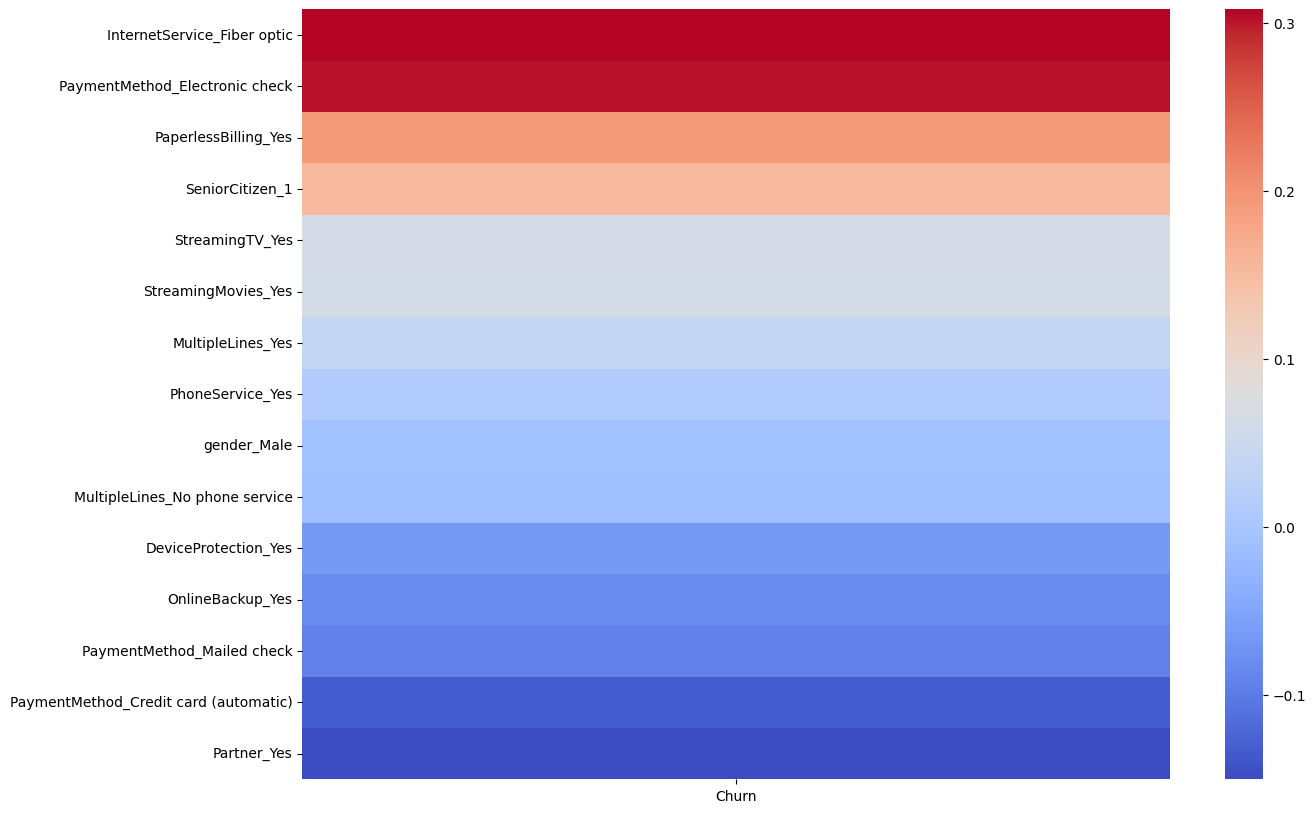

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df.drop(columns=[col for col in df.columns if "target_enc" in col])

corr_target = df_clean.corr()[["Churn"]].sort_values(by="Churn",ascending=False)
corr_target = corr_target.drop("Churn")

top_corr = corr_target.head(15)

plt.figure(figsize=(14,10))
sns.heatmap(top_corr,cmap='coolwarm')
plt.show()

In [19]:
selected_features = corr_target.sort_values(by="Churn", key=abs, ascending=False).head(10).index

In [20]:
x = df_clean[selected_features]
y = df_clean["Churn"]

In [21]:
x.columns

Index(['InternetService_Fiber optic', 'Contract_Two year',
       'PaymentMethod_Electronic check',
       'DeviceProtection_No internet service',
       'TechSupport_No internet service', 'StreamingTV_No internet service',
       'InternetService_No', 'StreamingMovies_No internet service',
       'OnlineBackup_No internet service',
       'OnlineSecurity_No internet service'],
      dtype='str')

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(x, y)

In [23]:
print(X_lda)

[[ 0.55301789]
 [-0.36962366]
 [-0.36962366]
 ...
 [ 0.55301789]
 [ 0.60068351]
 [-0.64505889]]


In [24]:
x = X_lda
y = y

In [25]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

log_model = LogisticRegression(max_iter=1000)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(log_model, x_train, y_train, cv=skf, scoring='accuracy')

print("Fold scores:", scores)
print("Mean accuracy:", scores.mean())

Fold scores: [0.74977817 0.76042591 0.74800355 0.7675244  0.76198934]
Mean accuracy: 0.7575442749499212


In [27]:
log_model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
y_predicted = log_model.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_predicted))

Test Accuracy: 0.7686302342086586


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1036
           1       0.58      0.48      0.52       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [31]:
from sklearn.ensemble import RandomForestClassifier

random_model = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(random_model, x_train, y_train, cv=skf)

print("Fold scores:", scores)
print("Mean accuracy:", scores.mean())

Fold scores: [0.74977817 0.76042591 0.74800355 0.7675244  0.76198934]
Mean accuracy: 0.7575442749499212


In [32]:
random_model.fit(x_train,y_train)

y_pred_random = random_model.predict(x_test)

In [33]:
print("Test Accuracy:", accuracy_score(y_test, y_pred_random))

Test Accuracy: 0.7686302342086586


In [34]:
print(classification_report(y_test, y_pred_random))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1036
           1       0.58      0.48      0.52       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [35]:
from xgboost import XGBClassifier

xg_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(xg_model, x_train, y_train, cv=skf)

print("Fold scores:", scores)
print("Mean accuracy:", scores.mean())

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:57:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:57:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:57:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:57:53] WARN

Fold scores: [0.74977817 0.76042591 0.74800355 0.7675244  0.76198934]
Mean accuracy: 0.7575442749499212


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:57:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
xg_model.fit(x_train,y_train)

y_pred_xg = xg_model.predict(x_test)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:57:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
print("Test Accuracy:", accuracy_score(y_test, y_pred_xg))

Test Accuracy: 0.7686302342086586


In [38]:
print(classification_report(y_test, y_pred_xg))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1036
           1       0.58      0.48      0.52       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

random_model_grid = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(random_model_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.7575434869290986


In [40]:
best_model = grid.best_estimator_

y_pred_cv = best_model.predict(x_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred_cv))

Test Accuracy: 0.7686302342086586


In [41]:
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1036
           1       0.58      0.48      0.52       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [42]:
from xgboost import XGBClassifier

xg_model_grid = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

grid = GridSearchCV(xg_model_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(x_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV score: 0.7575434869290986


In [43]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7686302342086586


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1036
           1       0.58      0.48      0.52       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



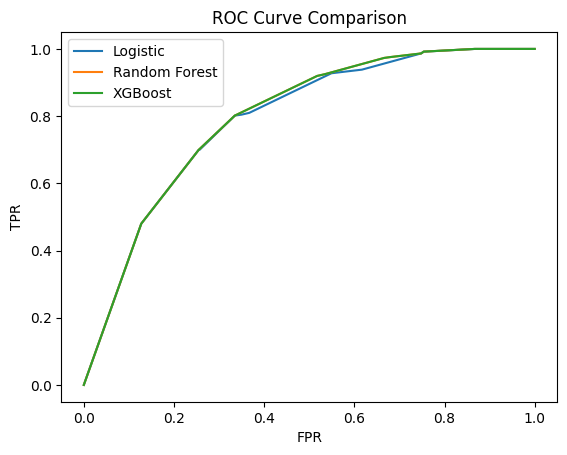

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Example for one model (repeat for others)
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_model.predict_proba(x_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, random_model.predict_proba(x_test)[:,1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xg_model.predict_proba(x_test)[:,1])

plt.plot(fpr_lr, tpr_lr, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()